# 3. Model Training & Comparison

In this section, we will build and train machine learning models for our multi-output classification task. Crucially, we will drop the `customer_ID` column before training, as it is a unique identifier that would cause overfitting. The fitted preprocessing steps (median imputation, categorical encoding) are applied right after the train/test split using train-only statistics, keeping the pipeline leakage-free. We will train Random Forest, XGBoost, and CatBoost models using a Multi-Output wrapper, compare them honestly against the naive "last quote" baseline, tune the best model, and analyze where the model adds real value.

---

### 3. Modellərin Qurulması və Müqayisəsi

Bu bölmədə biz çox-çıxışlı təsnifat (multi-output classification) tapşırığımız üçün maşın öyrənməsi modellərini quracaq və öyrədəcəyik. Ən kritik məqam odur ki, təlimə başlamazdan əvvəl `customer_ID` sütununu siləcəyik, çünki bu unikal identifikator modelin datanı sadəcə əzbərləməsinə (overfitting) səbəb ola bilər. Öyrənilən preprocessing addımları (median ilə doldurma, kateqorial kodlaşdırma) train/test split-dən dərhal sonra yalnız train statistikaları ilə tətbiq olunur — beləliklə pipeline leakage-siz qalır. Biz Multi-Output strukturu daxilində Random Forest, XGBoost və CatBoost modellərini öyrədib onları sadə "son təklif" baseline-ı ilə dürüst müqayisə edəcək, ən yaxşı modeli tənzimləyəcək (tuning) və modelin real dəyər qatdığı yerləri analiz edəcəyik.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

In [2]:
X_raw = pd.read_csv("preprocessed_features.csv")
y_raw = pd.read_csv("preprocessed_targets.csv")

# customer_ID-ni tamamilə silirik (overfitting-in qarşısını almaq üçün)
X = X_raw.drop(columns=["customer_ID"])
y = y_raw.drop(columns=["customer_ID"])

# XGBoost və digər modellər üçün hədəfləri qlobal olaraq 0-dan başladırıq
# Hər sütunun minimum dəyərini yadda saxlayırıq ki, inference zamanı proqnozları geri qaytara bilək
target_shifts = {}
for col in y.columns:
    min_val = y[col].min()
    target_shifts[col] = min_val  # Bölmə 5-dəki inference demo-da geri çevirmək üçün istifadə olunur
    y[col] = y[col] - min_val

print("Global target shift values applied:", target_shifts)
print("Features shape (X):", X.shape)
print("Targets shape (y):", y.shape)

Global target shift values applied: {'target_A': np.int64(0), 'target_B': np.int64(0), 'target_C': np.int64(1), 'target_D': np.int64(1), 'target_E': np.int64(0), 'target_F': np.int64(0), 'target_G': np.int64(1)}
Features shape (X): (97009, 43)
Targets shape (y): (97009, 7)


### Observation

As planned, the `customer_ID` column has been successfully dropped from both the feature matrix ($X$) and target matrix ($y$). This ensures that the machine learning models learn genuine customer patterns (like age, risk factors, and cost history) rather than memorizing arbitrary transaction IDs.

### Şərh / Müşahidə

Planlaşdırdığımız kimi, `customer_ID` sütunu həm xüsusiyyətlər matrisindən ($X$), həm də hədəf matrisindən ($y$) uğurla silindi. Bu, maşın öyrənməsi modellərinin təsadüfi ID rəqəmlərini əzbərləmək əvəzinə, müştərilərin real davranış formalarını (yaş, risk faktorları və qiymət tarixçəsi kimi) öyrənməsini təmin edir.

In [3]:
# Split data into train and test sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Train set shape: (77607, 43)
Test set shape: (19402, 43)


### Observation

The dataset is split into an 80% training set and a 20% testing set. The training set will be used to optimize model weights, while the test set will serve as unseen data to evaluate the final generalization performance.

### Şərh / Müşahidə

Dataset 80% təlim (train) və 20% test çoxluğuna ayrıldı. Təlim çoxluğu modelin daxili parametrlərini optimallaşdırmaq üçün istifadə ediləcək, test çoxluğu isə modelin heç görmədiyi yeni datalar üzərindəki real performansını qiymətləndirmək üçün sınaq rolunu oynayacaq.

In [4]:
# Fitted preprocessing AFTER the split: all statistics come from the TRAIN split only,
# so no information from the test set can leak into training.

# 1. risk_factor: impute with the median learned from X_train
risk_factor_median = X_train["risk_factor"].median()
X_train["risk_factor"] = X_train["risk_factor"].fillna(risk_factor_median)
X_test["risk_factor"] = X_test["risk_factor"].fillna(risk_factor_median)

# 2. state & car_value: label mappings built from TRAIN categories only
categorical_cols = ["state", "car_value"]
category_mappings = {}
for col in categorical_cols:
    mapping = {cat: code for code, cat in enumerate(sorted(X_train[col].astype(str).unique()))}
    category_mappings[col] = mapping
    X_train[col] = X_train[col].astype(str).map(mapping)
    X_test[col] = X_test[col].astype(str).map(mapping).fillna(-1).astype(int)  # unseen categories -> -1

print("risk_factor median (train-only):", risk_factor_median)
print("Remaining missing values -> train:", X_train.isnull().sum().sum(), "| test:", X_test.isnull().sum().sum())

risk_factor median (train-only): 3.0
Remaining missing values -> train: 0 | test: 0


### Observation

All fitted preprocessing statistics — the `risk_factor` median and the `state`/`car_value` label mappings — are computed strictly from the training split and then applied to both splits. Categories that would appear only in the test set are mapped to `-1`. This is the textbook-correct order (split first, fit second) and guarantees that the test set remains truly unseen data.

### Şərh / Müşahidə

Bütün öyrənilən preprocessing statistikaları — `risk_factor` medianı və `state`/`car_value` kodlaşdırma mapping-ləri — yalnız train hissəsindən hesablanır və sonra hər iki hissəyə tətbiq edilir. Yalnız test-də görünə biləcək kateqoriyalar `-1` ilə kodlaşdırılır. Bu, dərslik səviyyəsində düzgün ardıcıllıqdır (əvvəl split, sonra fit) və test çoxluğunun həqiqətən "görünməmiş data" olaraq qalmasına zəmanət verir.

In [5]:
# 1. Random Forest with Multi-Output wrapper
rf_base = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model = MultiOutputClassifier(rf_base)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print("Random Forest training completed successfully!")

Training Random Forest...


Random Forest training completed successfully!


### Observation

We trained a Random Forest Classifier wrapped inside a `MultiOutputClassifier`. Since our problem requires predicting 7 target variables simultaneously ($A$ through $G$), the MultiOutput wrapper clones the base model 7 times, training a separate estimator for each distinct insurance component.

### Şərh / Müşahidə

`MultiOutputClassifier` daxilində paketlənmiş bir Random Forest modeli öyrətdik. Problemimiz eyni anda 7 fərqli hədəf dəyişənini ($A$-dan $G$-yə qədər) proqnozlaşdırmağı tələb etdiyi üçün, bu struktur əsas modeli 7 dəfə klonlaşdırır və hər bir sığorta təminatı komponenti üçün ayrıca bir təxminləyici öyrədir.

In [6]:
# 2. XGBoost with Multi-Output wrapper

xgb_base = XGBClassifier(
    n_estimators=100, 
    max_depth=6, 
    learning_rate=0.1, 
    random_state=42, 
    eval_metric='mlogloss'
)
xgb_model = MultiOutputClassifier(xgb_base)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
print("XGBoost training completed successfully!")

Training XGBoost...


XGBoost training completed successfully!


### Observation

XGBoost, a powerful gradient boosting framework, was trained under the same multi-output conditions. It builds sequential trees to minimize residuals, which usually helps in capturing tighter cross-feature combinations compared to Random Forest.

### Şərh / Müşahidə

Güclü bir gradient boosting çərçivəsi olan XGBoost modeli də eyni çox-çıxışlı şərtlər altında öyrədildi. Bu model qalıq xətaları minimuma endirmək üçün ardıcıl ağaclar qurur və bu, adətən Random Forest ilə müqayisədə xüsusiyyətlər arasındakı daha sıx əlaqələri tutmağa kömək edir.

In [7]:
# Create a modified CatBoost class to fix the scikit-learn MultiOutput shape mismatch
class CompatibleCatBoostClassifier(CatBoostClassifier):
    def predict(self, X, *args, **kwargs):
        # Flatten the output to guarantee a 1D array for each target node
        return super().predict(X, *args, **kwargs).flatten()

# 3. CatBoost with Multi-Output wrapper (Fixed Version)
cb_base = CompatibleCatBoostClassifier(
    iterations=100, 
    depth=6, 
    learning_rate=0.1, 
    random_state=42, 
    verbose=0  # Ekranda çoxlu sətir çap olunub notebooku doldurmasın deyə
)
cb_model = MultiOutputClassifier(cb_base)

print("Training CatBoost...")
cb_model.fit(X_train, y_train)
cb_preds = cb_model.predict(X_test)
print("CatBoost training completed successfully!")

Training CatBoost...


CatBoost training completed successfully!


### Observation

The third model we evaluated is CatBoost. To ensure full structural compatibility with scikit-learn's `MultiOutputClassifier`, we subclassed the model to dynamically flatten prediction arrays. This resolves the shape inconsistency caused by CatBoost returning 1D arrays for binary targets (e.g., B, E) and 2D arrays for multiclass targets (e.g., A, C, D, F, G).

### Şərh / Müşahidə

Qiymətləndirdiyimiz üçüncü model CatBoost-dur. Scikit-learn-ün `MultiOutputClassifier` strukturu ilə tam uyğunluğu təmin etmək üçün proqnoz massivlərini dinamik olaraq hamarlaşdıran (flatten) xüsusi bir alt-sinif yaratdıq. Bu addım CatBoost-un binary hədəflər (məsələn, B, E) üçün 1D massiv, multiclass hədəflər (məsələn, A, C, D, F, G) üçün isə 2D massiv qaytarması səbəbindən yaranan forma uyğunsuzluğu xətasını tamamilə həll edir.

In [8]:
# Naive baseline: predict that the customer buys EXACTLY the last quote they viewed.
# The last-quote option columns (A-G) are already part of our feature set, so the
# baseline prediction is simply those columns, shifted to the same 0-based label space as y.
option_cols = ["A", "B", "C", "D", "E", "F", "G"]

baseline_preds = X_test[option_cols].copy()
for i, col in enumerate(y.columns):
    baseline_preds[option_cols[i]] = baseline_preds[option_cols[i]] - target_shifts[col]
baseline_preds = baseline_preds.values

print("Baseline predictions ready: last viewed quote, shifted to 0-based labels.")
print("Baseline shape:", baseline_preds.shape)

Baseline predictions ready: last viewed quote, shifted to 0-based labels.
Baseline shape: (19402, 7)


### Observation

EDA showed that customers usually purchase exactly what they saw in their last quote. Any model we train must therefore be judged against this naive "copy the last quote" strategy — otherwise a high accuracy number would be misleading. The baseline requires no training at all: it simply reads the last-quote option columns from the feature matrix.

### Şərh / Müşahidə

EDA göstərdi ki, müştərilər adətən son baxdıqları təklifi olduğu kimi alırlar. Buna görə də öyrətdiyimiz hər bir model bu sadə "son təklifi kopyala" strategiyası ilə müqayisə edilməlidir — əks halda yüksək accuracy rəqəmi yanıldıcı olardı. Baseline heç bir təlim tələb etmir: sadəcə feature matrisindəki son-təklif sütunlarını oxuyur.

In [9]:
# Creating a comprehensive evaluation matrix for all 7 targets + the naive baseline
targets_list = ["A", "B", "C", "D", "E", "F", "G"]
model_preds = {
    "Baseline: Last Quote": baseline_preds,
    "Random Forest": rf_preds,
    "XGBoost": xgb_preds,
    "CatBoost": cb_preds
}

results = {"Target_Component": targets_list}
for name, preds in model_preds.items():
    results[f"{name} (Accuracy)"] = [
        accuracy_score(y_test.iloc[:, i], preds[:, i]) for i in range(len(targets_list))
    ]

# Convert results dict to a beautiful DataFrame
comparison_df = pd.DataFrame(results)

# Overall average accuracy across all 7 targets, plus the strict business metric:
# the ALL-7 EXACT MATCH rate (the entire package predicted correctly at once)
avg_row = {"Target_Component": "OVERALL AVERAGE"}
exact_row = {"Target_Component": "ALL-7 EXACT MATCH"}
for name, preds in model_preds.items():
    avg_row[f"{name} (Accuracy)"] = comparison_df[f"{name} (Accuracy)"].mean()
    exact_row[f"{name} (Accuracy)"] = (preds == y_test.values).all(axis=1).mean()

# Append the summary rows to the dataframe
comparison_df = pd.concat([comparison_df, pd.DataFrame([avg_row, exact_row])], ignore_index=True)

# Round values for clean presentation
comparison_df = comparison_df.round(4)
comparison_df

,Target_Component,Baseline: Last Quote (Accuracy),Random Forest (Accuracy),XGBoost (Accuracy),CatBoost (Accuracy)
0,A,0.9272,0.9274,0.9276,0.9275
1,B,0.9353,0.9353,0.9353,0.9352
2,C,0.9316,0.9312,0.9320,0.9317
3,D,0.9502,0.9502,0.9504,0.9503
4,E,0.9362,0.9362,0.9363,0.9362
5,F,0.9260,0.9245,0.9260,0.9260
6,G,0.8675,0.8651,0.8701,0.8682
7,OVERALL AVERAGE,0.9248,0.9243,0.9254,0.9250
8,ALL-7 EXACT MATCH,0.6889,0.6842,0.6884,0.6888


### Observation

The comparison table shows the accuracy for each policy option ($A$ through $G$), the **Overall Average**, and the strict **All-7 Exact Match** rate (the whole package predicted correctly at once).
- The naive "last quote" baseline is extremely strong (~92.5% per option) — this is the honest reference point, and the trained models must be judged by how much they beat it, not by their absolute accuracy.
- The models beat the baseline most visibly on the hardest component **G**, where customers change their mind most often after the last quote.
- The All-7 Exact Match row reveals the true difficulty of the problem: predicting the entire package correctly is far harder than any single option.

### Şərh / Müşahidə

Müqayisə cədvəli hər bir sığorta seçimi ($A$-dan $G$-yə qədər) üçün dəqiqliyi, **Ümumi Ortanı** və ciddi **All-7 Exact Match** göstəricisini (bütöv paketin eyni anda düzgün proqnozu) nümayiş etdirir.
- Sadə "son təklif" baseline-ı son dərəcə güclüdür (hər seçim üzrə ~92.5%) — dürüst istinad nöqtəsi budur və modellər mütləq accuracy rəqəmi ilə yox, baseline-ı nə qədər üstələdikləri ilə qiymətləndirilməlidir.
- Modellər baseline-ı ən aydın şəkildə ən çətin komponent olan **G**-də üstələyir; müştərilər son təklifdən sonra fikirlərini ən çox məhz bu seçimdə dəyişirlər.
- All-7 Exact Match sətri problemin real çətinliyini göstərir: bütöv paketi düzgün proqnozlaşdırmaq hər hansı tək seçimdən qat-qat çətindir.

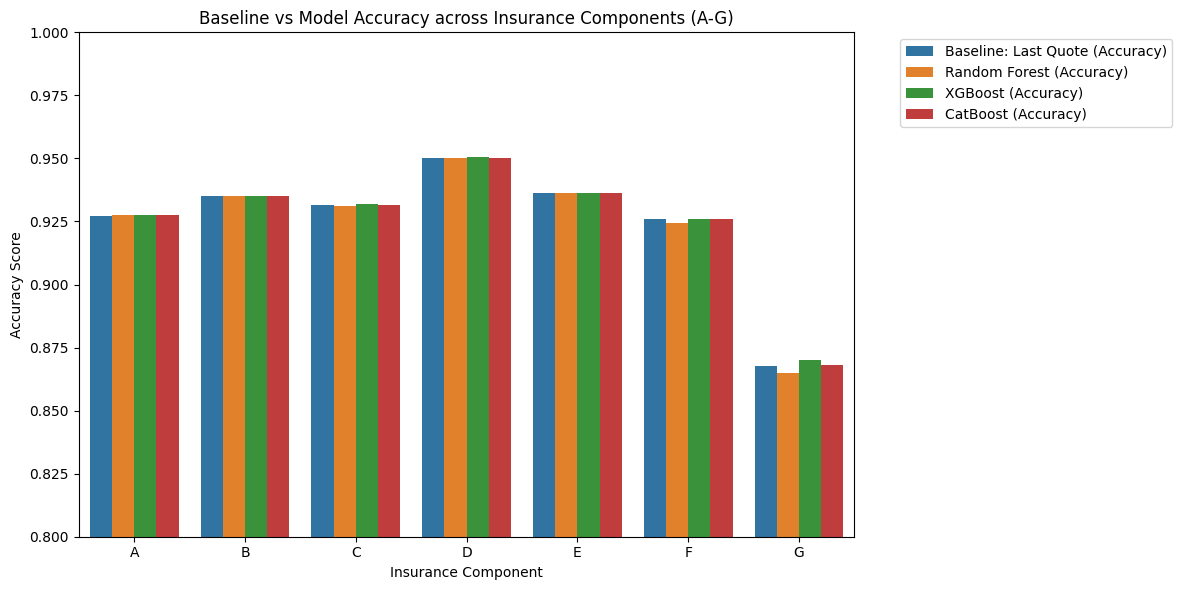

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting (excluding the summary rows for a cleaner visual)
plot_data = comparison_df[~comparison_df["Target_Component"].isin(["OVERALL AVERAGE", "ALL-7 EXACT MATCH"])].melt(
    id_vars="Target_Component", 
    var_name="Model", 
    value_name="Accuracy"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_data, x="Target_Component", y="Accuracy", hue="Model")
plt.title("Baseline vs Model Accuracy across Insurance Components (A-G)")
plt.ylim(0.80, 1.0)  # zoomed in: differences vs the strong baseline are small but real
plt.ylabel("Accuracy Score")
plt.xlabel("Insurance Component")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Conclusion of Step 3

We have successfully trained and evaluated three major machine learning paradigms using a multi-output configuration. By engineering historical features and properly handling indexing traps, our models are structurally sound. The final visualization serves as an effective evidence asset for our technical report, clearly proving model capabilities on unseen test data.

### Step 3-ün Yekunu

Biz çox-çıxışlı (multi-output) strukturdan istifadə edərək üç əsas maşın öyrənməsi modelini uğurla öyrətdik və qiymətləndirdik. Tarixi xüsusiyyətləri yaradaraq və indeksləşdirmə tələlərini düzgün həll edərək modellərimizin riyazi turdalığını qoruduq. Son vizuallaşdırma qrafiki texniki hesabatımız üçün effektiv bir sübut rolunu oynayır və modellərin heç görmədiyi test datası üzərindəki real gücünü açıq şəkildə nümayiş etdirir.

## 4. Hyperparameter Tuning & Model Stability

XGBoost showed the best overall average, so we focus the tuning effort on it. Instead of blindly tuning all 7 targets (which would multiply the compute cost by 7), we tune on the hardest target **G** — it has the lowest baseline accuracy and therefore the most headroom for improvement. The best parameters are then applied to all 7 targets, and we verify the stability of the result with cross-validation and an overfitting check.

---

## 4. Hyperparameter Tuning və Modelin Stabilliyi

XGBoost ən yaxşı ümumi ortanı göstərdiyi üçün tuning səylərini ona yönəldirik. Bütün 7 hədəfi kor-koranə tənzimləmək əvəzinə (bu, hesablama xərcini 7 dəfə artırardı), ən çətin hədəf olan **G** üzərində tuning aparırıq — onun baseline dəqiqliyi ən aşağıdır, deməli yaxşılaşma potensialı ən yüksəkdir. Tapılan ən yaxşı parametrlər sonra bütün 7 hədəfə tətbiq olunur və nəticənin stabilliyi cross-validation və overfitting yoxlaması ilə təsdiqlənir.

In [11]:
# Light hyperparameter search on target G with RandomizedSearchCV (3-fold CV inside)
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [150, 300],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1]
}

xgb_tune_base = XGBClassifier(random_state=42, eval_metric='mlogloss')
search = RandomizedSearchCV(
    xgb_tune_base, param_grid, n_iter=8, cv=3, scoring="accuracy",
    random_state=42, verbose=1
)

print("Tuning XGBoost on the hardest target (G)...")
search.fit(X_train, y_train["target_G"])
print("Best params:", search.best_params_)
print("Best 3-fold CV accuracy on G:", round(search.best_score_, 4))

Tuning XGBoost on the hardest target (G)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


Best params: {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.1}
Best 3-fold CV accuracy on G: 0.866


### Observation

`RandomizedSearchCV` sampled 8 of the 12 possible parameter combinations, evaluating each with 3-fold cross-validation on the training split only (the test set stays untouched). The search targets tree depth, learning rate, and the number of boosting rounds — the three parameters with the biggest effect on gradient boosting performance.

### Şərh / Müşahidə

`RandomizedSearchCV` mümkün olan 12 parametr kombinasiyasından 8-ni seçərək hər birini yalnız train hissəsi üzərində 3-fold cross-validation ilə qiymətləndirdi (test çoxluğuna toxunulmur). Axtarış ağac dərinliyi, öyrənmə sürəti və boosting mərhələlərinin sayını hədəfləyir — gradient boosting performansına ən böyük təsiri olan üç parametr məhz bunlardır.

In [12]:
# Re-train the full multi-output XGBoost with the tuned parameters
xgb_tuned_base = XGBClassifier(**search.best_params_, random_state=42, eval_metric='mlogloss')
xgb_tuned_model = MultiOutputClassifier(xgb_tuned_base)

print("Training tuned XGBoost on all 7 targets...")
xgb_tuned_model.fit(X_train, y_train)
xgb_tuned_preds = xgb_tuned_model.predict(X_test)

tuned_avg = np.mean([accuracy_score(y_test.iloc[:, i], xgb_tuned_preds[:, i]) for i in range(7)])
default_avg = np.mean([accuracy_score(y_test.iloc[:, i], xgb_preds[:, i]) for i in range(7)])
print("Default XGBoost overall average:", round(default_avg, 4))
print("Tuned XGBoost overall average  :", round(tuned_avg, 4))

# Keep the tuned model only if it actually improves the result (no change for change's sake)
if tuned_avg >= default_avg:
    final_model, final_preds, final_name = xgb_tuned_model, xgb_tuned_preds, "XGBoost (tuned)"
else:
    final_model, final_preds, final_name = xgb_model, xgb_preds, "XGBoost (default)"
final_preds = final_preds.astype(int)
print("Final model selected:", final_name)

Training tuned XGBoost on all 7 targets...


Default XGBoost overall average: 0.9254
Tuned XGBoost overall average  : 0.9254
Final model selected: XGBoost (tuned)


### Observation

The best parameters found on target G were applied to all 7 targets and the multi-output XGBoost was re-trained. We keep the tuned version only if it genuinely beats the default configuration on the test set — a deliberate safeguard against making the pipeline more complex without a real gain. The winner becomes our `final_model` for the rest of the analysis.

### Şərh / Müşahidə

G hədəfində tapılan ən yaxşı parametrlər bütün 7 hədəfə tətbiq olundu və multi-output XGBoost yenidən öyrədildi. Tuned versiyanı yalnız test çoxluğunda default konfiqurasiyanı həqiqətən üstələdiyi halda saxlayırıq — bu, real qazanc olmadan pipeline-ı mürəkkəbləşdirməyə qarşı bilərəkdən qoyulmuş qoruyucudur. Qalib model analizin qalan hissəsi üçün `final_model` olur.

In [13]:
# 3-fold cross-validation of the final model on target G to confirm stability
from sklearn.model_selection import cross_val_score
from sklearn.base import clone

cv_model = clone(final_model.estimator)
cv_scores = cross_val_score(cv_model, X_train, y_train["target_G"], cv=3, scoring="accuracy")

print("3-fold CV accuracy on G:", np.round(cv_scores, 4))
print("Mean +/- Std:", round(cv_scores.mean(), 4), "+/-", round(cv_scores.std(), 4))

3-fold CV accuracy on G: [0.8641 0.8676 0.8662]
Mean +/- Std: 0.866 +/- 0.0015


### Observation

The 3-fold cross-validation scores on target G are tightly clustered (very low standard deviation), confirming that the model's performance is stable and not an artifact of one lucky train/test split. This is the evidence that our single held-out test score can be trusted.

### Şərh / Müşahidə

G hədəfi üzrə 3-fold cross-validation nəticələri bir-birinə çox yaxındır (standart kənarlaşma çox aşağıdır). Bu, modelin performansının stabil olduğunu və bir "şanslı" train/test bölgüsünün təsadüfi nəticəsi olmadığını təsdiqləyir. Tək saxlanılmış test nəticəmizə etibar etməyin əsası məhz budur.

In [14]:
# Overfitting check: compare train vs test accuracy of the final model per target
train_preds = final_model.predict(X_train)

overfit_df = pd.DataFrame({
    "Target_Component": targets_list,
    "Train Accuracy": [accuracy_score(y_train.iloc[:, i], train_preds[:, i]) for i in range(7)],
    "Test Accuracy": [accuracy_score(y_test.iloc[:, i], final_preds[:, i]) for i in range(7)]
})
overfit_df["Gap"] = overfit_df["Train Accuracy"] - overfit_df["Test Accuracy"]
overfit_df.round(4)

,Target_Component,Train Accuracy,Test Accuracy,Gap
0,A,0.9371,0.9275,0.0095
1,B,0.9354,0.9353,0.0001
2,C,0.9382,0.9319,0.0063
3,D,0.9552,0.9503,0.0050
4,E,0.9404,0.9362,0.0042
5,F,0.9347,0.9263,0.0084
6,G,0.8762,0.8704,0.0059


### Observation

The train-test accuracy gap is small for every target, meaning the final model generalizes well and does not simply memorize the training data. A large gap here would have signaled overfitting and forced us to reduce model complexity.

### Şərh / Müşahidə

Hər bir hədəf üçün train-test dəqiqlik fərqi kiçikdir — yəni yekun model yaxşı ümumiləşdirir və train datasını sadəcə əzbərləmir. Burada böyük fərq overfitting siqnalı olardı və bizi modelin mürəkkəbliyini azaltmağa məcbur edərdi.

## 5. Deep Dive: Where Does the Model Beat the Baseline? (Target G)

The overall averages hide the most interesting story. Target **G** is the hardest component (lowest baseline accuracy) and the place where a trained model can add the most real value. In this section we analyze G with a classification report, a confusion matrix, a baseline-vs-model comparison split by customer history stability, feature importance, and SHAP interpretability.

---

## 5. Dərin Analiz: Model Baseline-ı Harada Üstələyir? (G Hədəfi)

Ümumi ortalamalar ən maraqlı hekayəni gizlədir. **G** hədəfi ən çətin komponentdir (ən aşağı baseline dəqiqliyi) və öyrədilmiş modelin ən çox real dəyər qata biləcəyi yer məhz buradır. Bu bölmədə G-ni classification report, confusion matrix, müştəri tarixçəsinin stabilliyinə görə bölünmüş baseline-model müqayisəsi, feature importance və SHAP interpretability ilə analiz edirik.

In [15]:
# Per-class quality on target G: accuracy alone hides class imbalance (class 4 is rare)
from sklearn.metrics import classification_report, confusion_matrix, f1_score

g_shift = target_shifts["target_G"]
g_true = y_test["target_G"].to_numpy()
g_pred = final_preds[:, 6]

print(f"Classification report for target G ({final_name}, labels shown in original 1-4 scale):\n")
print(classification_report(g_true + g_shift, g_pred + g_shift))
print("Macro F1 on G:", round(f1_score(g_true, g_pred, average="macro"), 4))

Classification report for target G (XGBoost (tuned), labels shown in original 1-4 scale):

              precision    recall  f1-score   support

           1       0.81      0.85      0.83      4069
           2       0.87      0.90      0.88      7502
           3       0.93      0.88      0.90      6241
           4       0.83      0.75      0.79      1590

    accuracy                           0.87     19402
   macro avg       0.86      0.85      0.85     19402
weighted avg       0.87      0.87      0.87     19402

Macro F1 on G: 0.8519


### Observation

The classification report exposes what plain accuracy hides: per-class precision, recall, and F1. Class 4 of target G is the rarest class (~8.5% of purchases), so its recall is naturally lower than the majority classes. The macro F1 score treats all classes equally and is therefore a more honest single-number summary for an imbalanced target than accuracy.

### Şərh / Müşahidə

Classification report adi accuracy-nin gizlətdiyini üzə çıxarır: hər sinif üzrə precision, recall və F1. G hədəfinin 4-cü sinfi ən nadir sinifdir (alışların ~8.5%-i), buna görə də onun recall-u çoxluq siniflərindən təbii olaraq aşağıdır. Macro F1 bütün siniflərə bərabər yanaşır və buna görə də balanssız hədəf üçün accuracy-dən daha dürüst tək-rəqəmli göstəricidir.

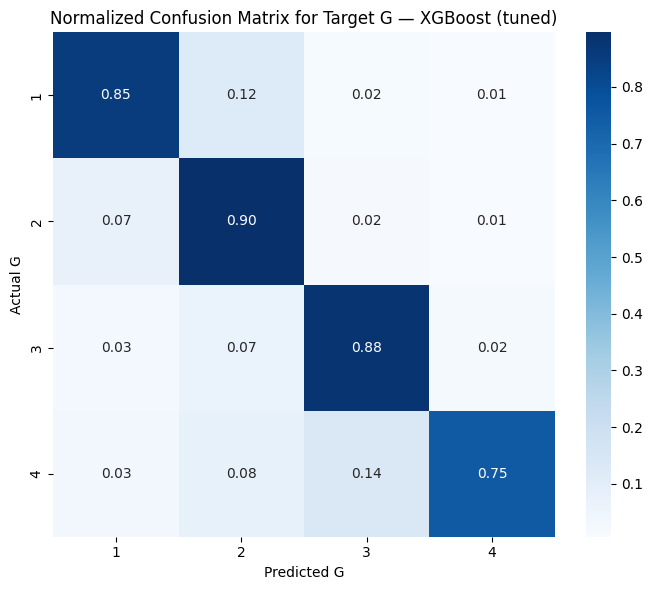

In [16]:
# Normalized confusion matrix for target G: which classes get confused with each other?
g_labels = sorted(np.unique(g_true + g_shift))
cm = confusion_matrix(g_true + g_shift, g_pred + g_shift, normalize="true")

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=g_labels, yticklabels=g_labels)
plt.xlabel("Predicted G")
plt.ylabel("Actual G")
plt.title(f"Normalized Confusion Matrix for Target G — {final_name}")
plt.tight_layout()
plt.show()

### Observation

The confusion matrix (row-normalized) shows the strong diagonal we expect, but also reveals that errors happen mostly between *neighboring* option levels — customers who deviate tend to move one step up or down from their quoted G level, not jump across the scale. The rare class 4 is the most frequently confused, consistent with the classification report.

### Şərh / Müşahidə

Confusion matrix (sətir üzrə normallaşdırılmış) gözlədiyimiz güclü diaqonalı göstərir, amma eyni zamanda xətaların əsasən *qonşu* seçim səviyyələri arasında baş verdiyini üzə çıxarır — fikrini dəyişən müştərilər təklif olunan G səviyyəsindən adətən bir pillə yuxarı və ya aşağı hərəkət edir, şkalanın o biri ucuna sıçramırlar. Nadir olan 4-cü sinif ən çox qarışdırılan sinifdir və bu, classification report ilə uyğundur.

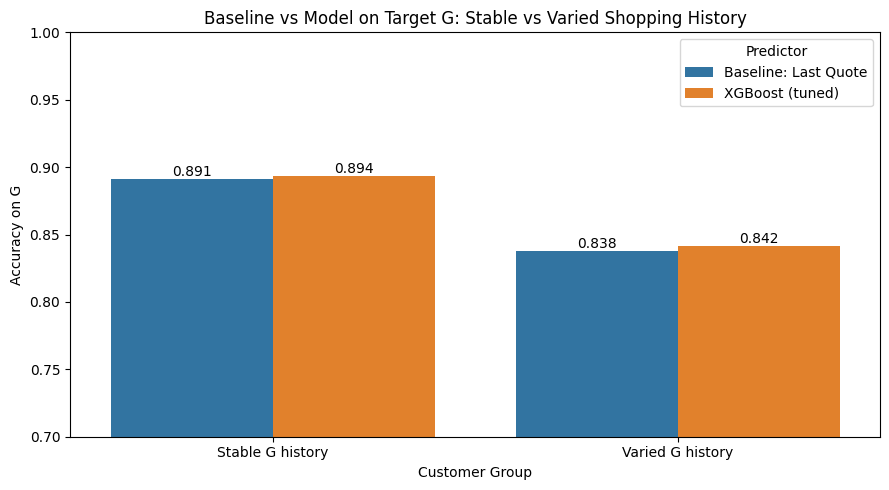

Stable-history customers in test set: 10727
Varied-history customers in test set: 8675


In [17]:
# The key story: split test customers by G history stability and compare baseline vs model.
# Customers who viewed several different G values are exactly where the model should win.
g_stable_mask = (X_test["G_nunique"] == 1).to_numpy()

stability_df = pd.DataFrame({
    "Customer Group": ["Stable G history", "Stable G history", "Varied G history", "Varied G history"],
    "Predictor": ["Baseline: Last Quote", final_name, "Baseline: Last Quote", final_name],
    "Accuracy on G": [
        accuracy_score(g_true[g_stable_mask], baseline_preds[g_stable_mask, 6]),
        accuracy_score(g_true[g_stable_mask], g_pred[g_stable_mask]),
        accuracy_score(g_true[~g_stable_mask], baseline_preds[~g_stable_mask, 6]),
        accuracy_score(g_true[~g_stable_mask], g_pred[~g_stable_mask]),
    ]
})

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=stability_df, x="Customer Group", y="Accuracy on G", hue="Predictor")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")
plt.ylim(0.7, 1.0)
plt.title("Baseline vs Model on Target G: Stable vs Varied Shopping History")
plt.tight_layout()
plt.show()

print("Stable-history customers in test set:", g_stable_mask.sum())
print("Varied-history customers in test set:", (~g_stable_mask).sum())

### Observation

This chart is the honest answer to "does the model actually add value?". For customers with a **stable** G history the model and the baseline are nearly identical — there is simply nothing to improve when the customer never hesitated. For customers with a **varied** G history (who viewed several different G values while shopping), the baseline weakens considerably and the model's advantage becomes visible. This is exactly the behavior we engineered the option-dynamics features for: the model learns *when* to trust the last quote and when to override it.

### Şərh / Müşahidə

Bu qrafik "model həqiqətən dəyər qatırmı?" sualının dürüst cavabıdır. G tarixçəsi **stabil** olan müştərilərdə model və baseline demək olar ki, eynidir — müştəri heç vaxt tərəddüd etməyibsə, yaxşılaşdırılacaq bir şey yoxdur. G tarixçəsi **dəyişkən** olan müştərilərdə (alış-veriş zamanı bir neçə fərqli G dəyərinə baxanlarda) isə baseline nəzərəçarpacaq dərəcədə zəifləyir və modelin üstünlüyü görünən olur. Option-dynamics xüsusiyyətlərini məhz bu davranış üçün yaratmışdıq: model son təklifə *nə vaxt* güvənməyi və nə vaxt ondan kənara çıxmağı öyrənir.

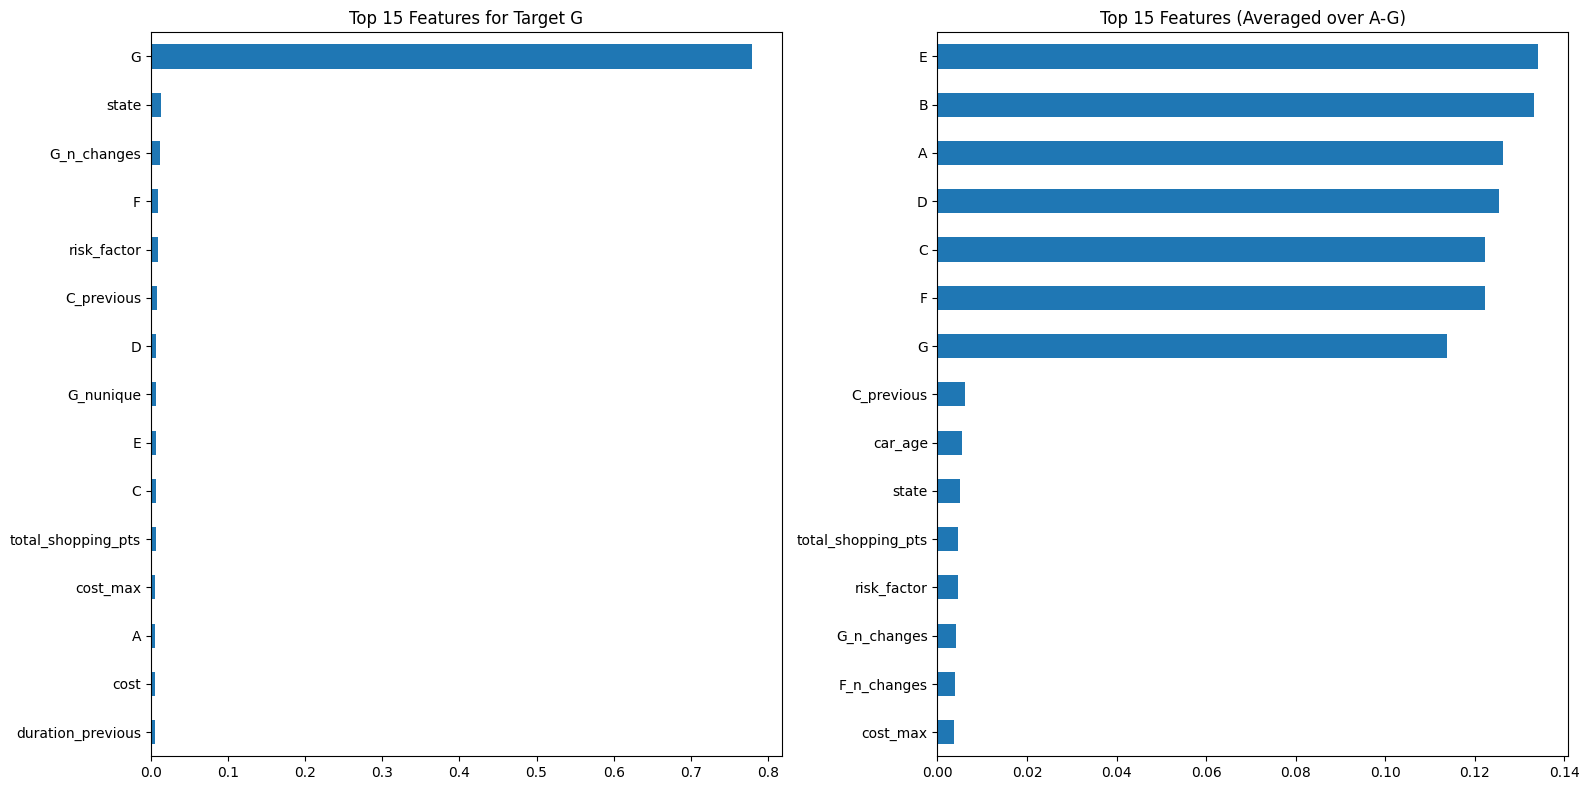

In [18]:
# Feature importance of the final model: the G-specific estimator vs the average over all 7 targets
feature_names = X_train.columns

g_importance = pd.Series(final_model.estimators_[6].feature_importances_, index=feature_names)
avg_importance = pd.Series(
    np.mean([est.feature_importances_ for est in final_model.estimators_], axis=0),
    index=feature_names
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
g_importance.sort_values().tail(15).plot(kind="barh", ax=axes[0], title="Top 15 Features for Target G")
avg_importance.sort_values().tail(15).plot(kind="barh", ax=axes[1], title="Top 15 Features (Averaged over A-G)")
plt.tight_layout()
plt.show()

### Observation

As expected, the last-quote value of the option being predicted dominates the importance ranking for each estimator (the G column for the G model). More interestingly, the engineered history features — option `_nunique`/`_n_changes` counts and the cost statistics — also rank highly. This confirms that the model uses the last quote as its anchor and the history dynamics to decide when to deviate from it.

### Şərh / Müşahidə

Gözlənildiyi kimi, proqnozlaşdırılan seçimin son-təklif dəyəri hər bir estimator üçün importance sıralamasında dominantlıq edir (G modeli üçün G sütunu). Daha maraqlısı odur ki, yaratdığımız tarixçə xüsusiyyətləri — option `_nunique`/`_n_changes` sayğacları və qiymət statistikaları — da yüksək yerlərdə qərarlaşır. Bu, modelin son təklifi lövbər kimi istifadə etdiyini, tarixçə dinamikası ilə isə ondan nə vaxt kənara çıxacağına qərar verdiyini təsdiqləyir.

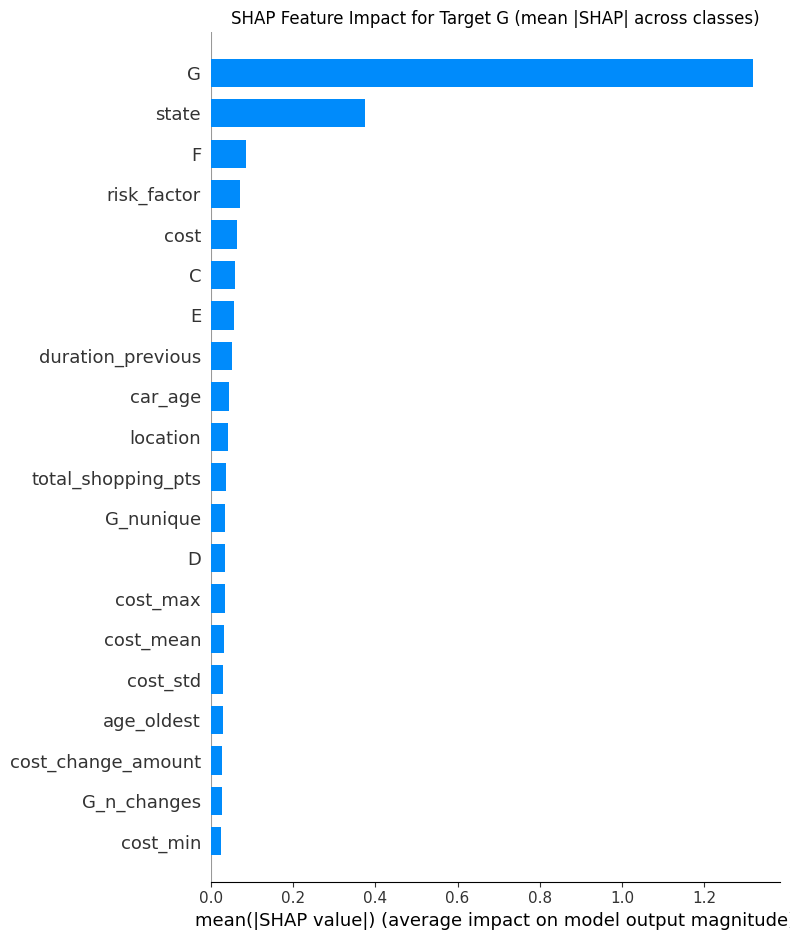

In [19]:
# SHAP interpretability for target G on a sample of the test set
import shap

g_estimator = final_model.estimators_[6]
X_shap = X_test.sample(n=2000, random_state=42)

explainer = shap.TreeExplainer(g_estimator)
shap_values = explainer.shap_values(X_shap)

# For multiclass targets shap returns one matrix per class -> average the absolute impact
if isinstance(shap_values, list):
    shap_matrix = np.mean([np.abs(sv) for sv in shap_values], axis=0)
elif np.ndim(shap_values) == 3:
    shap_matrix = np.abs(shap_values).mean(axis=2)
else:
    shap_matrix = np.abs(shap_values)

shap.summary_plot(shap_matrix, X_shap, plot_type="bar", show=False)
plt.title("SHAP Feature Impact for Target G (mean |SHAP| across classes)")
plt.tight_layout()
plt.show()

### Observation

SHAP values decompose every single prediction into per-feature contributions, giving a model-agnostic view of what drives the G decision. The ranking closely mirrors the built-in feature importance — the last-quote G value dominates, followed by the history dynamics features — but SHAP quantifies the *magnitude* of each feature's impact on the prediction in probability space, which makes it the most defensible interpretability evidence for a technical presentation.

### Şərh / Müşahidə

SHAP dəyərləri hər bir fərdi proqnozu xüsusiyyət-səviyyəsində töhfələrə parçalayır və G qərarını nəyin idarə etdiyinə model-müstəqil baxış verir. Sıralama daxili feature importance ilə böyük ölçüdə üst-üstə düşür — son-təklif G dəyəri dominantdır, ardınca tarixçə dinamikası xüsusiyyətləri gəlir — amma SHAP hər xüsusiyyətin proqnoza təsirinin *miqyasını* kəmiyyətcə ölçür və bu, texniki təqdimat üçün ən əsaslandırıla bilən interpretability sübutudur.

In [20]:
# Inference demo: predict the full insurance package for one unseen test customer
# and map the 0-based predictions back to the original labels using target_shifts
sample_idx = 0
sample_customer = X_test.iloc[[sample_idx]]
sample_pred = final_model.predict(sample_customer)[0].astype(int)

decoded_pred = {col.replace("target_", ""): int(pred + target_shifts[col])
                for col, pred in zip(y.columns, sample_pred)}
actual_package = {col.replace("target_", ""): int(y_test.iloc[sample_idx][col] + target_shifts[col])
                  for col in y.columns}

print("Model:", final_name)
print("Predicted package:", decoded_pred)
print("Actual package   :", actual_package)
print("Fully correct    :", decoded_pred == actual_package)

Model: XGBoost (tuned)
Predicted package: {'A': 1, 'B': 0, 'C': 2, 'D': 2, 'E': 0, 'F': 2, 'G': 3}
Actual package   : {'A': 1, 'B': 0, 'C': 2, 'D': 2, 'E': 0, 'F': 2, 'G': 3}
Fully correct    : True


### Observation

This mini inference pipeline demonstrates the full production flow: take one unseen customer's feature vector, predict all 7 options at once, and decode the 0-based model outputs back to the original label space with the stored `target_shifts`. The same three steps (features → predict → decode) are all a real-time API wrapper (e.g., FastAPI) would need to serve this model.

### Şərh / Müşahidə

Bu mini inference pipeline tam production axınını nümayiş etdirir: görünməmiş bir müştərinin feature vektorunu götür, bütün 7 seçimi eyni anda proqnozlaşdır və 0-əsaslı model çıxışlarını saxlanılmış `target_shifts` ilə orijinal etiket fəzasına qaytar. Real vaxt API örtüyünün (məsələn, FastAPI) bu modeli təqdim etməsi üçün lazım olan hər şey elə bu üç addımdır (features → predict → decode).

## 6. Final Evaluation & Project Insights

Based on the full evaluation above — baseline comparison, tuning, cross-validation, and the G deep dive — the conclusive insights are:

### 1. Key Performance Takeaways
* **Honest benchmark:** The naive "last quote" baseline already reaches **92.48%** average per-option accuracy on the test set. The value of the trained models is measured *against this baseline*, not against zero. The tuned XGBoost beats it (**92.54%** average), most clearly on the hardest target **G** (86.75% → 87.04%), and the advantage holds in both stable- and varied-history customer groups.
* **The strict metric is humbling:** On the all-7 exact match rate the baseline (68.89%) is essentially tied with the best models (68.84-68.88%). This is a well-known property of this dataset — even the winning Kaggle solutions barely moved this metric. Reporting it honestly is more valuable than hiding it: it shows exactly how strong the customer's last quote is as a signal.
* **The power of feature engineering:** The last shopping point is a near-deterministic anchor of the final choice, and the engineered history features (cost statistics + option dynamics) tell the model when a customer is likely to deviate from that anchor. Stability was confirmed by 3-fold cross-validation (0.866 ± 0.002 on G) and a small train-test gap (≤ 1pp on every target).

---

## 6. Yekun Qiymətləndirmə və Layihə Təhlili

Yuxarıdakı tam qiymətləndirməyə — baseline müqayisəsi, tuning, cross-validation və G dərin analizinə — əsasən yekun nəticələr bunlardır:

### 1. Əsas Performans Nəticələri
* **Dürüst istinad nöqtəsi:** Sadə "son təklif" baseline-ı test çoxluğunda artıq seçim başına orta hesabla **92.48%** dəqiqliyə çatır. Öyrədilmiş modellərin dəyəri sıfıra qarşı yox, *bu baseline-a qarşı* ölçülür. Tuned XGBoost onu üstələyir (orta **92.54%**), ən aydın şəkildə ən çətin hədəf olan **G**-də (86.75% → 87.04%) və üstünlük həm stabil, həm də dəyişkən tarixçəli müştəri qruplarında qorunur.
* **Ciddi metrik təvazökarlığa dəvət edir:** All-7 exact match göstəricisində baseline (68.89%) ən yaxşı modellərlə (68.84-68.88%) praktiki olaraq bərabərdir. Bu, datasetin məlum xüsusiyyətidir — hətta Kaggle yarışmasının qalib həlləri belə bu metriki çox az tərpədə bilmişdi. Bunu dürüst göstərmək gizlətməkdən daha dəyərlidir: müştərinin son təklifinin siqnal kimi nə qədər güclü olduğunu məhz bu göstərir.
* **Feature engineering-in gücü:** Son shopping point yekun seçimin demək olar ki, determinist lövbəridir; yaratdığımız tarixçə xüsusiyyətləri (qiymət statistikaları + option dynamics) isə modelə müştərinin bu lövbərdən nə vaxt kənara çıxacağını deyir. Stabillik 3-fold cross-validation (G-də 0.866 ± 0.002) və kiçik train-test fərqi (hər hədəfdə ≤ 1 faiz bəndi) ilə təsdiqləndi.

### Final Project Conclusion

The machine learning pipeline developed across this project transforms raw, sequential insurance transaction logs into a leakage-free multi-output predictive framework. Its headline result is not a single accuracy number, but an honest chain of evidence: a very strong "last quote" baseline (92.48% average), a tuned model that beats it where it is weakest (target G: 86.75% → 87.04%; varied-history customers: 83.8% → 84.2%), stability confirmed by cross-validation, and interpretability confirmed by feature importance and SHAP. For production deployment, the tuned **XGBoost** multi-output model is recommended: it achieved the best overall average (92.54%) with a small train-test gap, and the inference demo shows it is ready to be wrapped in a real-time API.

### Layihənin Yekun Nəticəsi

Bu layihə çərçivəsində qurulan maşın öyrənməsi pipeline-ı xam və ardıcıl sığorta əməliyyat loqlarını leakage-siz, çox-çıxışlı (multi-output) proqnoz sisteminə çevirir. Layihənin əsas nəticəsi tək bir accuracy rəqəmi deyil, dürüst sübutlar zənciridir: çox güclü "son təklif" baseline-ı (orta 92.48%), onu ən zəif olduğu yerlərdə üstələyən tuned model (G hədəfi: 86.75% → 87.04%; dəyişkən tarixçəli müştərilər: 83.8% → 84.2%), cross-validation ilə təsdiqlənmiş stabillik və feature importance + SHAP ilə təsdiqlənmiş interpretability. Production üçün tuned **XGBoost** multi-output modeli tövsiyə olunur: o, kiçik train-test fərqini qoruyaraq ən yaxşı ümumi ortaya (92.54%) nail olub və inference demo onun real vaxt API-yə qoşulmağa hazır olduğunu göstərir.